In [2]:
library(car)
library(caret)
library(glmnet)
library(tidyr)
library(corrplot)
source("config.R")

# Data

## Dataset Overview

In [3]:
bike.data <- read.csv(DAY_DATA)

str(bike.data)

'data.frame':	731 obs. of  16 variables:
 $ instant   : int  1 2 3 4 5 6 7 8 9 10 ...
 $ dteday    : chr  "2011-01-01" "2011-01-02" "2011-01-03" "2011-01-04" ...
 $ season    : int  1 1 1 1 1 1 1 1 1 1 ...
 $ yr        : int  0 0 0 0 0 0 0 0 0 0 ...
 $ mnth      : int  1 1 1 1 1 1 1 1 1 1 ...
 $ holiday   : int  0 0 0 0 0 0 0 0 0 0 ...
 $ weekday   : int  6 0 1 2 3 4 5 6 0 1 ...
 $ workingday: int  0 0 1 1 1 1 1 0 0 1 ...
 $ weathersit: int  2 2 1 1 1 1 2 2 1 1 ...
 $ temp      : num  0.344 0.363 0.196 0.2 0.227 ...
 $ atemp     : num  0.364 0.354 0.189 0.212 0.229 ...
 $ hum       : num  0.806 0.696 0.437 0.59 0.437 ...
 $ windspeed : num  0.16 0.249 0.248 0.16 0.187 ...
 $ casual    : int  331 131 120 108 82 88 148 68 54 41 ...
 $ registered: int  654 670 1229 1454 1518 1518 1362 891 768 1280 ...
 $ cnt       : int  985 801 1349 1562 1600 1606 1510 959 822 1321 ...


In [4]:
result.na <- data.frame(
  Total_Observations = nrow(bike.data),
  Missing_Values     = sum(is.na(bike.data))
)
print(result.na, row.names = FALSE)


 Total_Observations Missing_Values
                731              0


In [5]:
preprocess <- function(df) {
  df$instant    <- NULL
  df$dteday     <- NULL
  df$casual     <- NULL
  df$registered <- NULL
  
  df$season     <- factor(df$season, levels = 1:4,
                          labels = c("Winter", "Spring", "Summer", "Fall"))
  df$yr         <- as.factor(df$yr)
  df$mnth       <- as.factor(df$mnth)
  df$holiday    <- factor(df$holiday,    levels = c(0, 1))
  df$weekday    <- factor(df$weekday,    levels = 0:6)
  df$workingday <- factor(df$workingday, levels = c(0, 1))
  df$weathersit <- as.factor(df$weathersit)
  
  return(df)
}

bike.data <- preprocess(bike.data)

In [6]:
check_missing <- function(df, df.name = "") {
  missing.idx <- which(!complete.cases(df))
  cat(df.name, ": Found", length(missing.idx), "missing rows\n")
  if (length(missing.idx) > 0) print(df[missing.idx, ], row.names = FALSE)
  invisible(missing.idx)
}

check_missing(bike.data, "bike.data")

bike.data : Found 0 missing rows


# Exploratory Data Analysis

## Feature Distribution

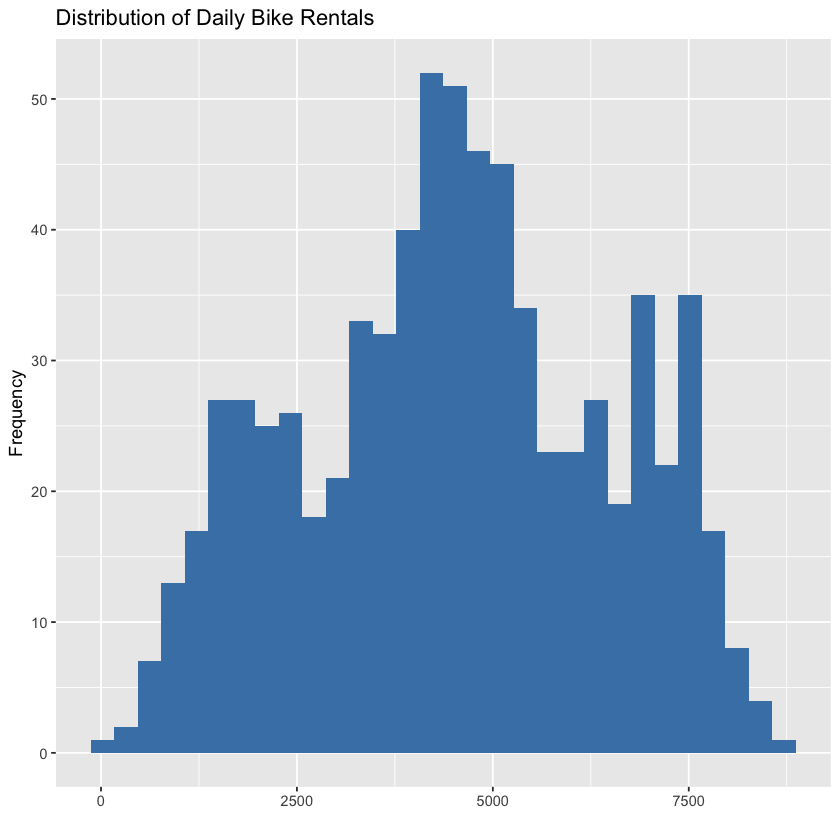

In [7]:
ggplot(bike.data, aes(x = cnt)) +
  geom_histogram(fill = "steelblue", bins = 30) +
  labs(title = "Distribution of Daily Bike Rentals",
       x = "", y = "Frequency")

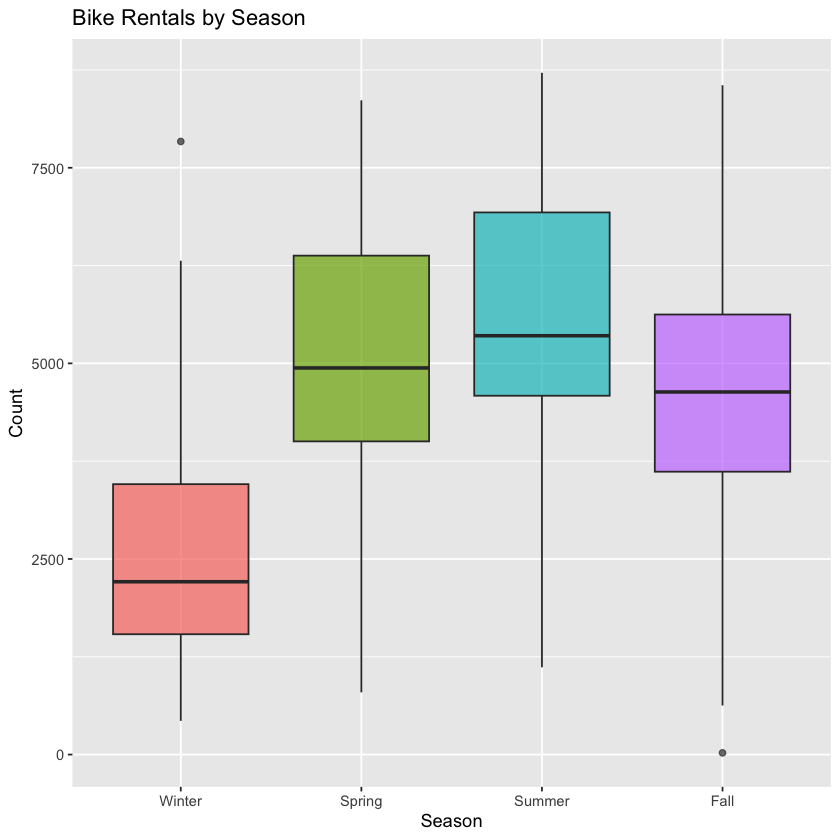

In [8]:
ggplot(bike.data, aes(x = season, y = cnt, fill = season)) +
  geom_boxplot(alpha = 0.7) +
  labs(title = "Bike Rentals by Season", x = "Season", y = "Count") +
  theme(legend.position = "none")

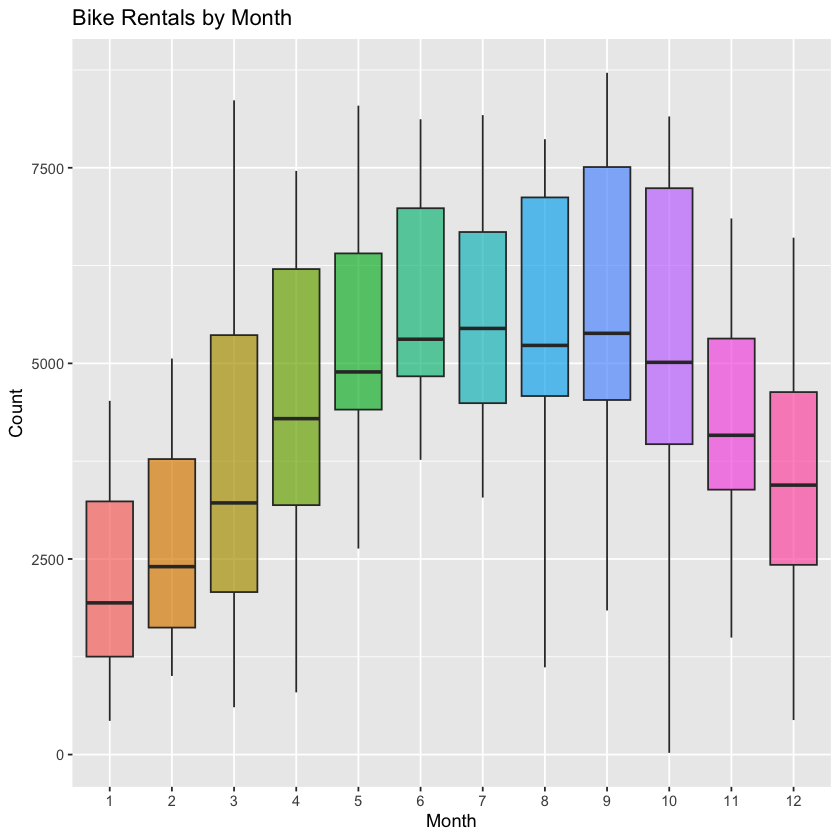

In [9]:
ggplot(bike.data, aes(x = mnth, y = cnt, fill = mnth)) +
  geom_boxplot(alpha = 0.7) +
  labs(title = "Bike Rentals by Month", x = "Month", y = "Count") +
  theme(legend.position = "none")

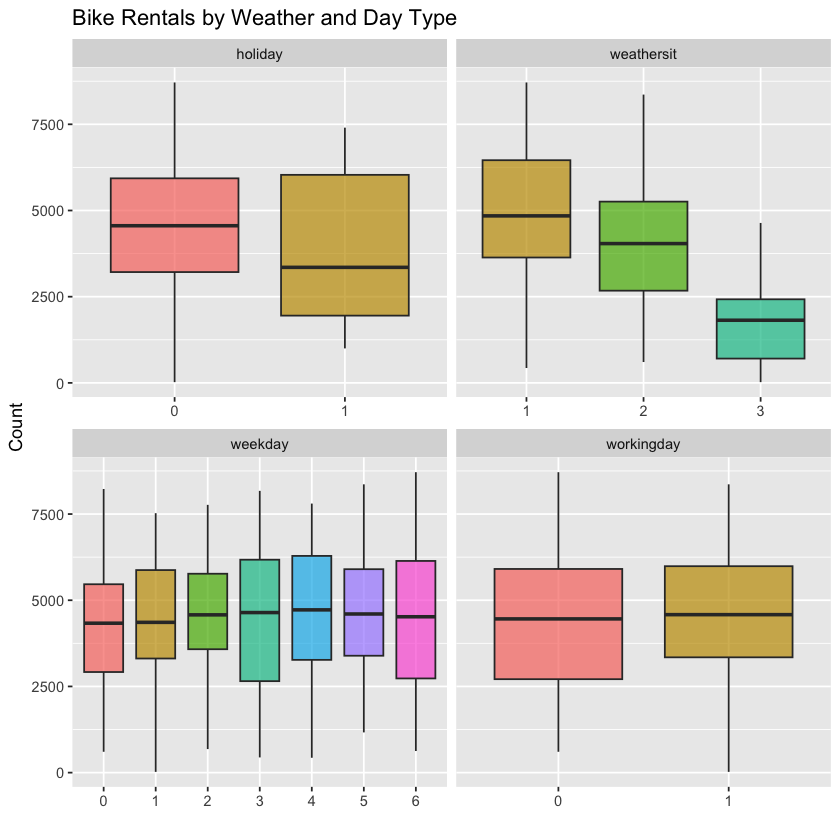

In [10]:
cat.group2 <- c("weathersit", "holiday", "weekday", "workingday")

df.cat2 <- pivot_longer(
  data = bike.data[, c("cnt", cat.group2)],
  cols = -cnt,
  names_to = "feature",
  values_to = "value",
  values_transform = list(value = as.character)
)

df.cat2$value <- factor(df.cat2$value,
                        levels = as.character(sort(unique(as.numeric(df.cat2$value)))))

ggplot(df.cat2, aes(x = value, y = cnt, fill = value)) +
  geom_boxplot(alpha = 0.7) +
  facet_wrap(~feature, scales = "free_x") +
  labs(title = "Bike Rentals by Weather and Day Type",
       x = "", y = "Count") +
  theme(legend.position = "none")

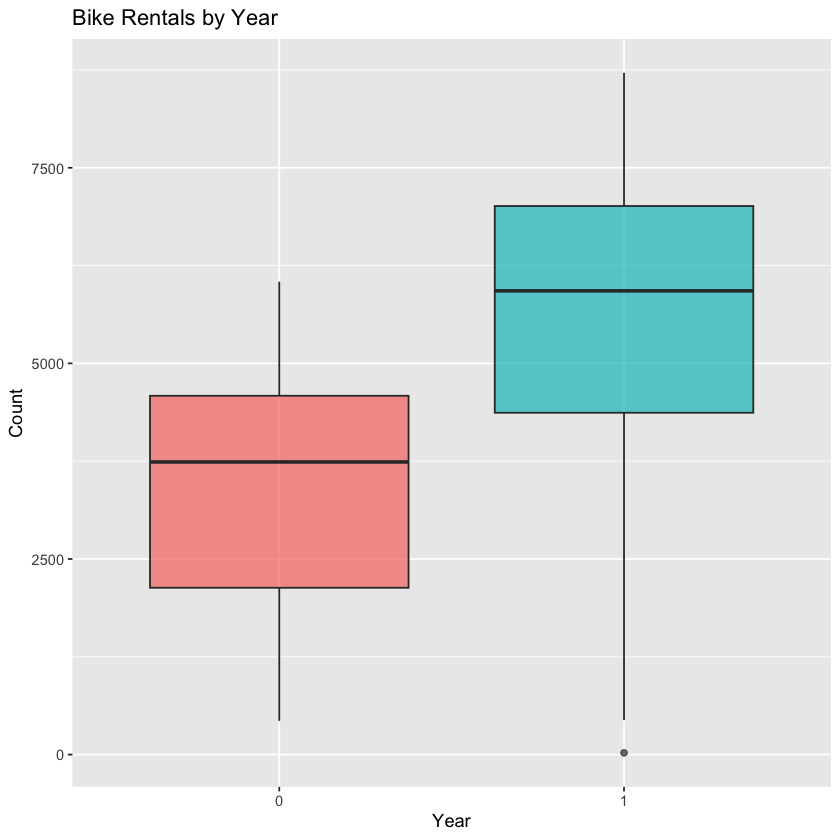

In [11]:
ggplot(bike.data, aes(x = yr, y = cnt, fill = yr)) +
  geom_boxplot(alpha = 0.7) +
  labs(title = "Bike Rentals by Year", x = "Year", y = "Count") +
  theme(legend.position = "none")

`geom_smooth()` using formula = 'y ~ x'


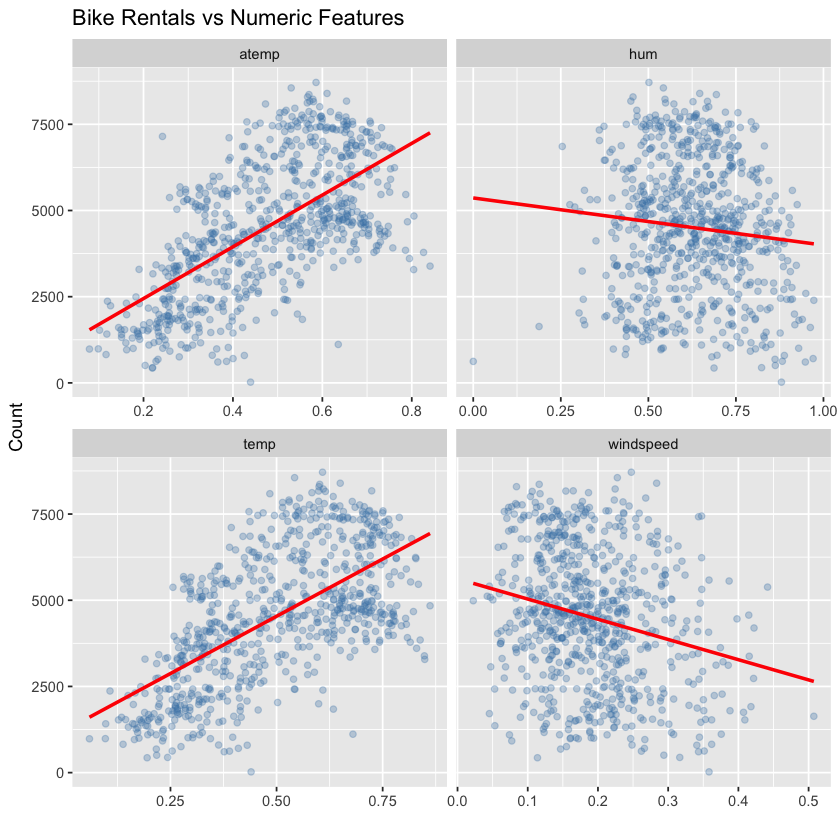

In [12]:
numeric.features <- c("temp", "atemp", "hum", "windspeed")

df.num.long <- pivot_longer(data = bike.data[, c("cnt", numeric.features)],
                            cols = -cnt,
                            names_to = "feature",
                            values_to = "value")

ggplot(df.num.long, aes(x = value, y = cnt)) +
  geom_point(alpha = 0.3, color = "steelblue") +
  geom_smooth(method = "lm", color = "red", se = FALSE) +
  facet_wrap(~feature, scales = "free_x") +
  labs(title = "Bike Rentals vs Numeric Features",
       x = "", y = "Count")

## Feature Correlation

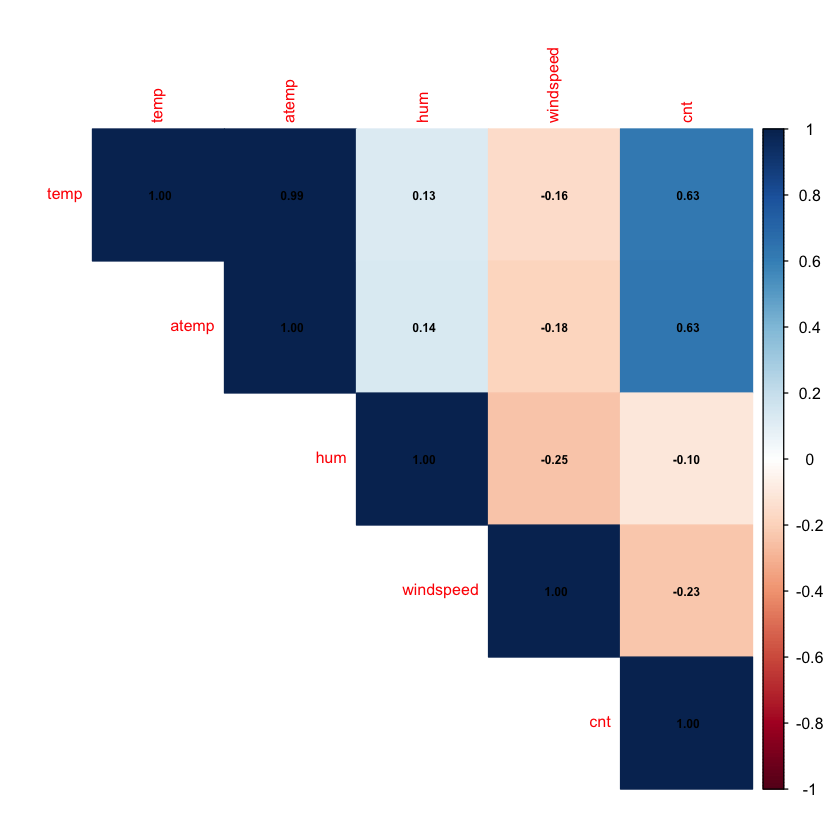

In [13]:
numeric.features <- c("temp", "atemp", "hum", "windspeed", "cnt")
cor.data <- bike.data[, numeric.features]

corrplot(cor(cor.data, use = "complete.obs"),
    method = "color",
    type = "upper",
    tl.cex = 0.8, 
    addCoef.col = "black",
    number.cex = 0.6)

## Multicollinearity Check (VIF)

In [14]:
compute_vif <- function(data) {
  lm.proxy <- lm(cnt ~ . - atemp - mnth - workingday, data = data)
  vif.result <- vif(lm.proxy)
  vif.data <- data.frame(
    Feature = rownames(vif.result),
    VIF     = round(vif.result[, 1], 3)
  )
  print(vif.data, row.names = FALSE)
  invisible(vif.data)
}

compute_vif(bike.data)

    Feature   VIF
     season 3.542
         yr 1.031
    holiday 1.092
    weekday 1.132
 weathersit 1.828
       temp 3.414
        hum 1.930
  windspeed 1.190


## OLS Regression

In [15]:
ctrl <- trainControl(method = "cv", number = 5)

train_lm <- function(data, ctrl) {
  set.seed(42)
  model <- train(cnt ~ season + yr + weekday + holiday +
                   temp + hum + windspeed + weathersit,
                 data = data,
                 method = "lm",
                 trControl = ctrl)
  return(model)
}

lm.model <- train_lm(bike.data, ctrl)
summary(lm.model$finalModel)


Call:
lm(formula = .outcome ~ ., data = dat)

Residuals:
    Min      1Q  Median      3Q     Max 
-3643.3  -368.8    68.1   478.8  3127.4 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)   1313.55     233.54   5.624 2.67e-08 ***
seasonSpring  1139.25     112.44  10.132  < 2e-16 ***
seasonSummer   842.92     148.50   5.676 2.00e-08 ***
seasonFall    1543.87      95.72  16.129  < 2e-16 ***
yr1           2017.14      61.14  32.993  < 2e-16 ***
weekday1       210.27     115.69   1.817 0.069564 .  
weekday2       295.75     113.06   2.616 0.009090 ** 
weekday3       364.05     113.33   3.212 0.001375 ** 
weekday4       388.73     113.27   3.432 0.000634 ***
weekday5       428.46     113.30   3.782 0.000169 ***
weekday6       441.84     112.66   3.922 9.64e-05 ***
holiday1      -663.79     188.27  -3.526 0.000449 ***
temp          5090.75     304.04  16.744  < 2e-16 ***
hum          -1220.91     293.82  -4.155 3.64e-05 ***
windspeed    -2779.82     424.02  -

# Assumption Diagnostics

## Residuals vs Fitted

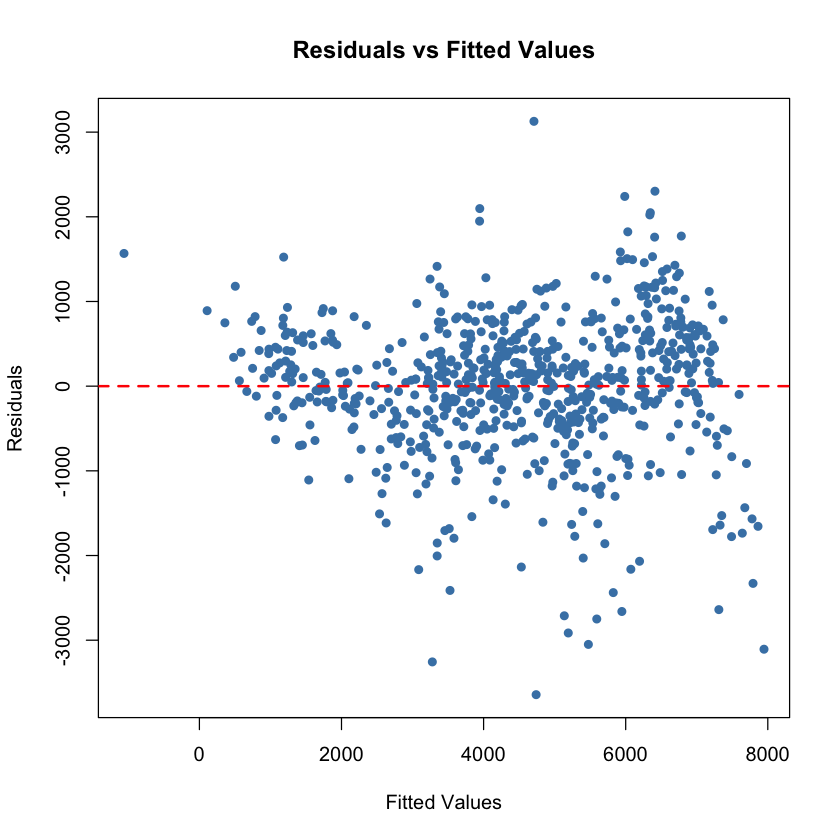

In [16]:
fitted.vals <- fitted(lm.model$finalModel)
residuals.vals <- residuals(lm.model$finalModel)

plot(fitted.vals, residuals.vals,
     main = "Residuals vs Fitted Values",
     xlab = "Fitted Values", 
     ylab = "Residuals",
     pch = 16, 
     col = "steelblue")

abline(h = 0, col = "red", lty = 2, lwd = 2)

## Normal Q-Q Plot

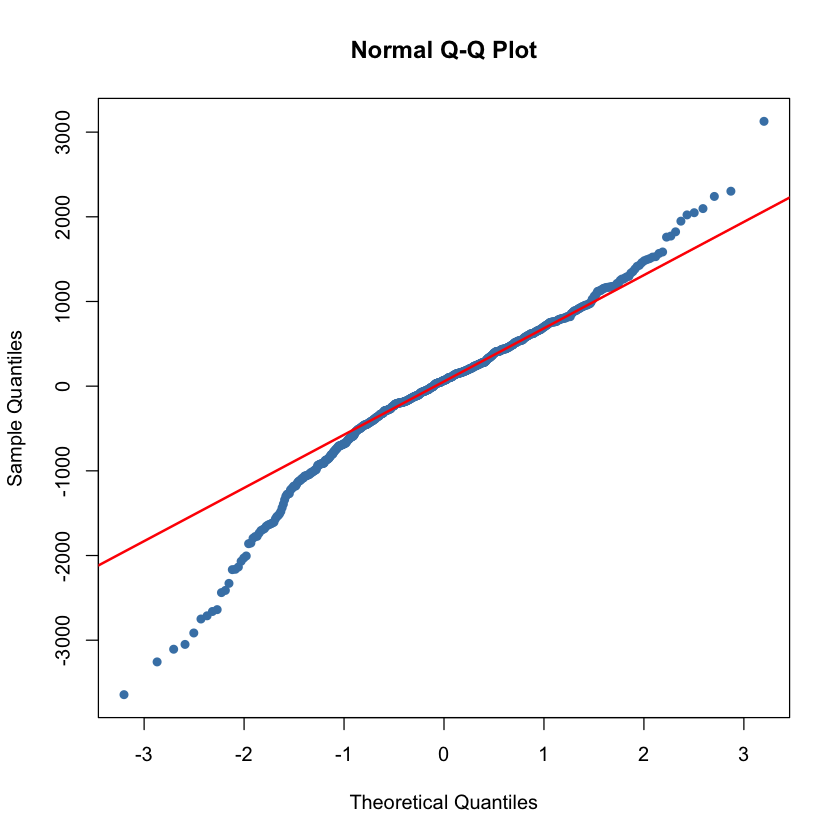

In [17]:
qqnorm(residuals.vals,
       main = "Normal Q-Q Plot",
       pch = 16,
       col = "steelblue")

qqline(residuals.vals, col = "red", lwd = 2)

## Scale-Location

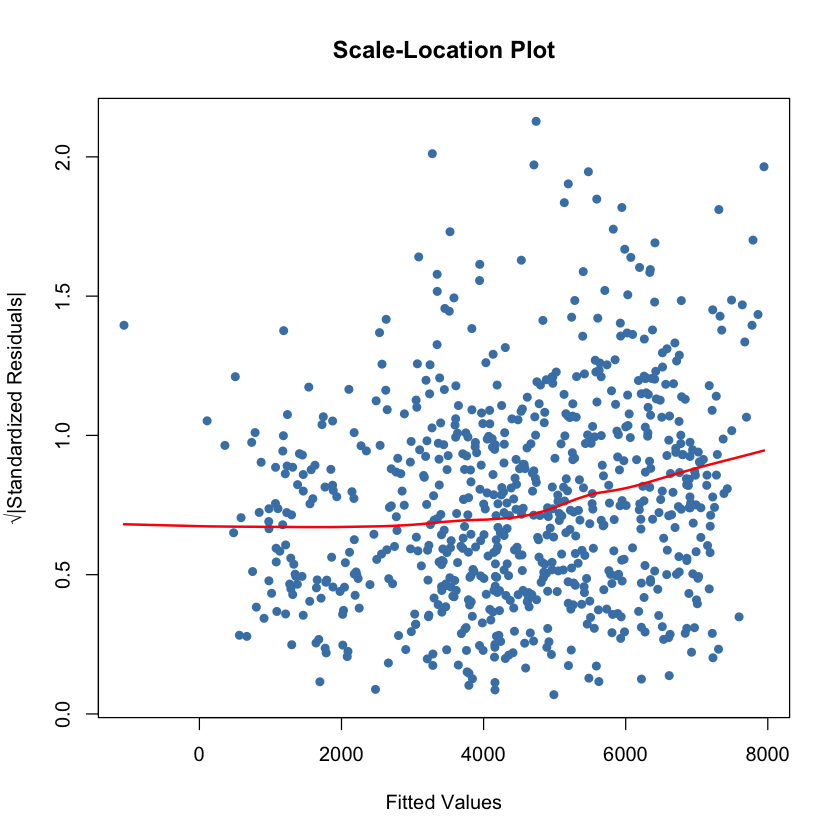

In [18]:
residuals.vals <- residuals(lm.model$finalModel)
standardized.residuals <- residuals.vals / sd(residuals.vals)
fitted.vals <- fitted(lm.model$finalModel)

plot(fitted.vals, sqrt(abs(standardized.residuals)),
     main = "Scale-Location Plot",
     xlab = "Fitted Values",
     ylab = "√|Standardized Residuals|",
     pch = 16,
     col = "steelblue")

lines(lowess(fitted.vals, sqrt(abs(standardized.residuals))),
      col = "red", lwd = 2)

## Cook's Distance

Influential points: 39 


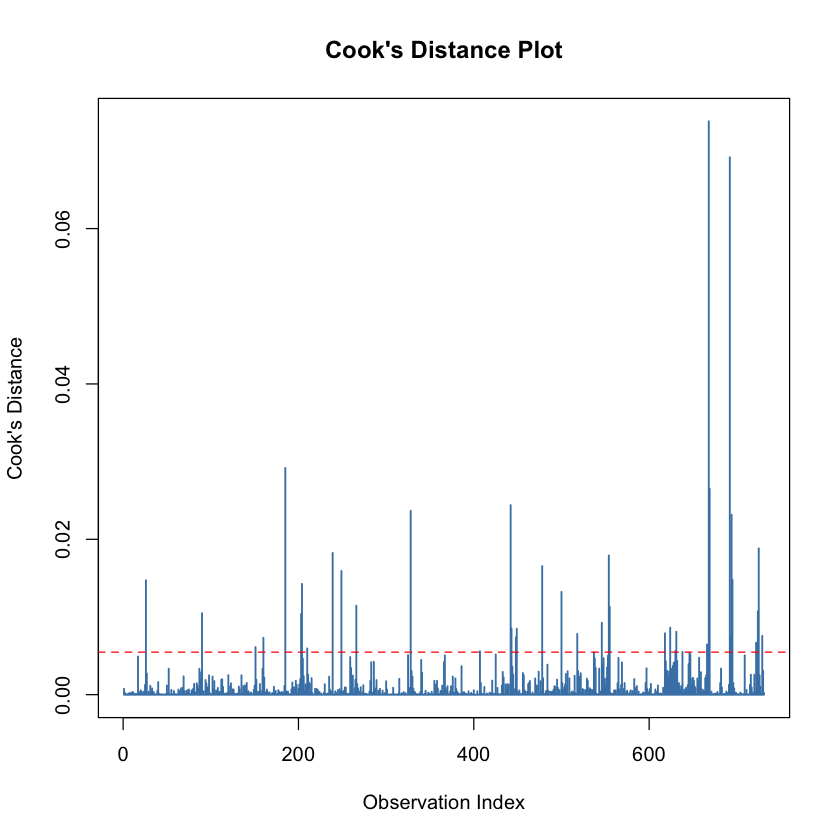

In [20]:
cooks.d <- cooks.distance(lm.model$finalModel)

plot(cooks.d, 
     type = "h",
     main = "Cook's Distance Plot",
     xlab = "Observation Index",
     ylab = "Cook's Distance",
     col = "steelblue",
     lwd = 1.5)

abline(h = 4/nrow(bike.data), col = "red", lty = 2)

cat("Influential points:", sum(cooks.d > 4/nrow(bike.data)), "\n")

# Regularisation

In [21]:
X <- model.matrix(cnt ~ season + yr + weekday + holiday +
                    temp + hum + windspeed + weathersit, 
                  data = bike.data)[, -1]
y <- bike.data$cnt

In [22]:
cv.lasso <- cv.glmnet(X, y, alpha = 1, nfolds = 5)
cv.ridge <- cv.glmnet(X, y, alpha = 0, nfolds = 5)

best.lambda.lasso <- cv.lasso$lambda.min
best.lambda.ridge <- cv.ridge$lambda.min

lasso.model <- glmnet(X, y, alpha = 1, lambda = best.lambda.lasso)
ridge.model <- glmnet(X, y, alpha = 0, lambda = best.lambda.ridge)

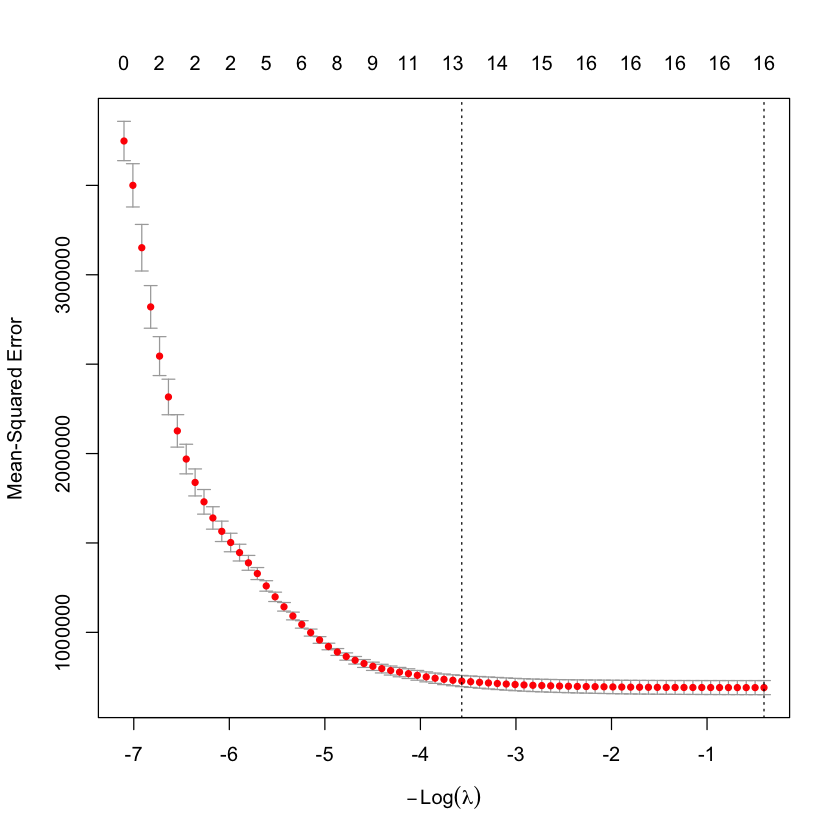

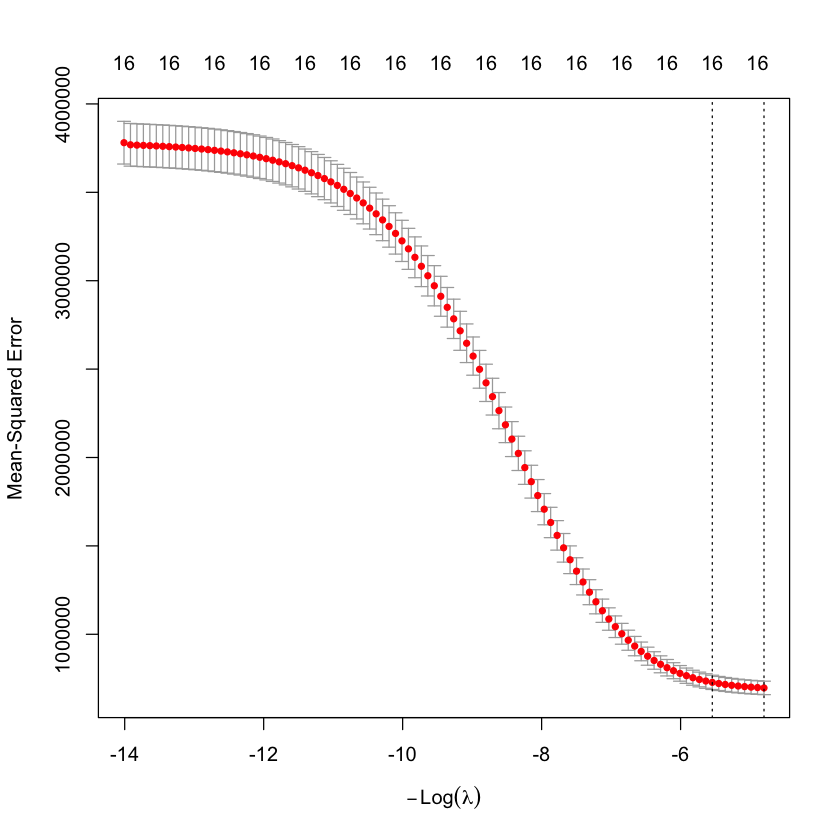

In [23]:
plot(cv.lasso)
plot(cv.ridge)

In [24]:
cat("Best lambda Ridge:", best.lambda.lasso, "\n")
cat("Best lambda Lasso:", best.lambda.ridge, "\n")

Best lambda Ridge: 1.497609 
Best lambda Lasso: 121.4757 


In [25]:
cat("Ridge - CV RMSE:", sqrt(min(cv.ridge$cvm)), "\n")
cat("Lasso - CV RMSE:", sqrt(min(cv.lasso$cvm)), "\n")
cat("OLS - CV RMSE:", min(lm.model$results$RMSE), "\n")

Ridge - CV RMSE: 834.6167 
Lasso - CV RMSE: 831.1769 
OLS - CV RMSE: 821.9861 


In [26]:
ridge.pred <- predict(ridge.model, newx = X)
lasso.pred <- predict(lasso.model, newx = X)

ridge.r2 <- 1 - sum((y - ridge.pred)^2) / sum((y - mean(y))^2)
lasso.r2 <- 1 - sum((y - lasso.pred)^2) / sum((y - mean(y))^2)

cat("OLS R²:", summary(lm.model$finalModel)$r.squared, "\n")
cat("Ridge R²:", ridge.r2, "\n")
cat("Lasso R²:", lasso.r2, "\n")

OLS R²: 0.8273739 
Ridge R²: 0.824011 
Lasso R²: 0.8273422 
